# **What are the most demanded skills for the top 3 most popular data roles?**

### Methodology

1. Clean and standardize the skills data
2. Identify the most common data roles
3. Measure skill demand within each role
4. Normalize demand using percentages
5. Compare skill profiles across roles

## 1. Import Libraries and Data

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## 2. Filter Data for the United States

In [2]:
# Filtering for United States
df_US = df[df['job_country']=='United States'].copy()

## 3. Explode Skills Column
The `job_skills` column contains multiple skills stored within a single row.
To accurately measure demand, we first clean and convert this column into a structured list format.

We then explode the column so that each skill appears in its own row.

This transformation allows us to properly aggregate and count skill occurrences.

In [3]:
# Exploding the job_skills column to have one skill per row
df_skills = df_US.explode('job_skills')

df_skills[['job_title', 'job_skills']]

,job_title,job_skills
0,Senior Clinical Data Engineer / Principal Clin...,NaN
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,python
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,c++
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,java
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,matlab
...,...,...
785692,Data Scientist- Hybrid Work Location,r
785703,Data Analyst - CRYPTOGRAPHY - Full-time,NaN
785705,Expert Business Data Analyst - Now Hiring,sql
785705,Expert Business Data Analyst - Now Hiring,python


## 4. Count Skills per Job Title
With the data structured correctly in `df_skills_count` data frame, we group by `job_title_short` and `job_skills` to calculate how often each skill appears within each role.

At this stage, we now understand raw skill demand across different data positions.

In [4]:
# Group by job_skills and job_title_short and count the number of occurrences
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()

# Name the count column as count
df_skills_count = df_skills_count.reset_index(name='skill_count')

# Sort the values by skill_count in descending order
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

df_skills_count

,job_skills,job_title_short,skill_count
1209,python,Data Scientist,42379
1521,sql,Data Analyst,34452
1523,sql,Data Scientist,30034
455,excel,Data Analyst,27519
1243,r,Data Scientist,26022
...,...,...,...
1785,vue.js,Business Analyst,1
60,arch,Business Analyst,1
71,asana,Machine Learning Engineer,1
968,no-sql,Machine Learning Engineer,1


## 5. Create List of Top 3 Roles
Before comparing skill demand, we first determine which roles appear most frequently in the dataset.

In [5]:
# Top 3 Job Titles
job_titles = df_skills_count['job_title_short'].unique().tolist()

job_titles = sorted(job_titles[:3])

job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

## 6. Count Total Postings for Different Job Title
Since each role may have a different number of job postings, we calculate total postings per role and saved it into `df_job_title_count`.

These totals act as the denominator when converting skill counts into percentages.

This step ensures our comparison is fair and not biased by posting volume.

In [6]:
# Job Count For Different Job Titles
df_job_title_count = df_US['job_title_short'].value_counts().reset_index(name='jobs_total') # Use original df to get the count of job titles

df_job_title_count

,job_title_short,jobs_total
0,Data Analyst,67816
1,Data Scientist,58830
2,Data Engineer,35080
3,Senior Data Scientist,12946
4,Senior Data Analyst,11791
5,Senior Data Engineer,9289
6,Business Analyst,7382
7,Software Engineer,1814
8,Machine Learning Engineer,921
9,Cloud Engineer,423


## 7. Convert Counts to Percentages

In [7]:
# merge skill counts with job totals and compute percent of postings asking for each skill
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, on='job_title_short', how='left')

# calculate percentage of jobs requiring each skill
df_skills_perc['skill_percent'] = (df_skills_perc['skill_count'] / df_skills_perc['jobs_total']) * 100

df_skills_perc

,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,python,Data Scientist,42379,58830,72.036376
1,sql,Data Analyst,34452,67816,50.802171
2,sql,Data Scientist,30034,58830,51.052184
3,excel,Data Analyst,27519,67816,40.578919
4,r,Data Scientist,26022,58830,44.232534
...,...,...,...,...,...
1865,vue.js,Business Analyst,1,7382,0.013546
1866,arch,Business Analyst,1,7382,0.013546
1867,asana,Machine Learning Engineer,1,921,0.108578
1868,no-sql,Machine Learning Engineer,1,921,0.108578


## 8. Plot Percentage Count
The visualization compares the percentage of job postings requiring specific skills across the three most frequently occurring data roles.

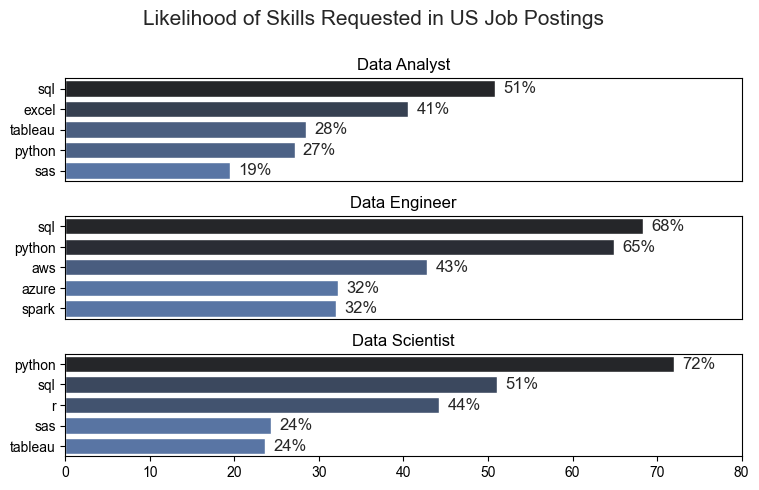

In [8]:
# create a figure with one subplot per job title
fig, ax = plt.subplots(len(job_titles), 1)
sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    # select top 5 skills for this job
    df_plot = df_skills_perc[df_skills_perc['job_title_short']==job_title].head(5)
    sns.barplot(
        data=df_plot,
        x='skill_percent',
        y='job_skills',
        hue='skill_count',
        palette='dark:b_r',
        ax=ax[i],
        legend=False
    )
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_xlim(0, 80)

    # hide x-axis ticks for all but the last subplot to reduce clutter
    if i != len(job_titles) - 1:
        ax[i].set_xticks([])

    # annotate each bar with the percentage value
    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center')

# add an overarching title and tidy up layout
fig.suptitle('Likelihood of Skills Requested in US Job Postings', fontsize=15)
fig.tight_layout(h_pad=.8)
fig.set_size_inches(8, 5)
plt.show()